# -------V1 Erste Schritt-------

In [ ]:
#!pip install torch torchvision numpy matplotlib

## 1- Import der Bibliotheken

In [1]:
# Schritt 1: Import der Bibliotheken
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
print(torch.cuda.is_available())

False


## 2- Daten Vorbereitung und Herunterladen

In [64]:
# Schritt 2: Datenvorbereitung

# Transformationen (Normalisierung und ggf. Augmentierung)
# Transformation festlegen: Bilder in Tensor umwandeln und normalisieren


transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Augmentierung 1
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Augmentierung 2
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

In [65]:
# CIFAR-10 Trainings- und Testdatensatz herunterladen

import random

def create_balanced_subset(dataset, samples_per_class):
    targets = np.array(dataset.targets)
    class_indices = []

    for class_id in range(10):  # Für CIFAR-10 (10 Klassen)
        idx = np.where(targets == class_id)[0]
        selected = np.random.choice(idx, samples_per_class, replace=False)
        class_indices.extend(selected)

    random.shuffle(class_indices)
    return Subset(dataset, class_indices)

# CIFAR-10-Daten herunterladen (Transformationen werden später hinzugefügt)
full_trainset = datasets.CIFAR10(root='./data', train=True, download=True)
full_testset = datasets.CIFAR10(root='./data', train=False, download=True)

# 200 Beispiele pro Klasse → insgesamt 2.000 Trainingsbeispiele
trainset = create_balanced_subset(full_trainset, 200)
# 50 Beispiele pro Klasse → insgesamt 500 Testbeispiele
testset = create_balanced_subset(full_testset, 50)

# Transformationen separat anwenden:
trainset.dataset.transform = transform_train
testset.dataset.transform = transform_test

print(f"Train set: {len(trainset)} Bilder")
print(f"Test set: {len(testset)} Bilder")


Train set: 2000 Bilder
Test set: 500 Bilder


In [66]:
# Trainings- und Validierungsgrößen definieren
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size

# Datensatz aufteilen (Split)
trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])

# Transformationen separat anwenden
trainset.dataset.transform = transform_train  # Mit Augmentierung
valset.dataset.transform = transform_test     # Nur Normalisierung


# Ausgabe zur Kontrolle
print(f'Trainingsdaten: {len(trainset)} Bilder')
print(f'Validierungsdaten: {len(valset)} Bilder')
print(f'Testdaten: {len(testset)} Bilder')


Trainingsdaten: 1600 Bilder
Validierungsdaten: 400 Bilder
Testdaten: 500 Bilder


In [67]:
# DataLoader erzeugen (Batchgröße = 4)

batch_size = 64

# DataLoader erstellen
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader   = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


# Klassen definieren (auf Deutsch)
classes = ('Flugzeug', 'Auto', 'Vogel', 'Katze', 'Hirsch',
           'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW')

## Visualisieren der Dateibildern

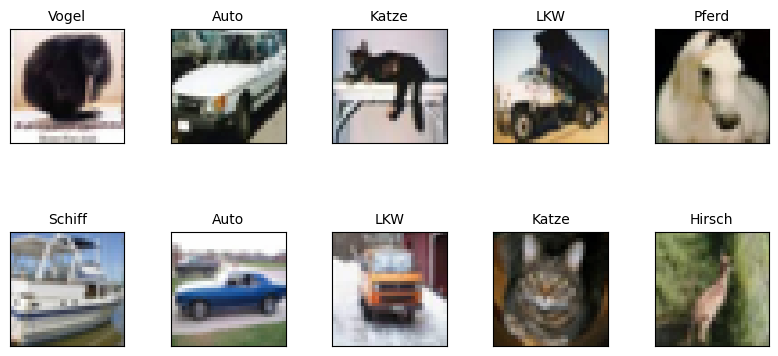

In [68]:
# Beispielbilder aus Testdaten holen
examples = enumerate(testloader)
batch_idx, (example_data, example_targets) = next(examples)

# Funktion zum Denormalisieren der Bilder
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)

# Visualisierung von 12 kleinen Beispielbildern (4x3 Layout)
fig = plt.figure(figsize=(8,6))
for i in range(10):
    plt.subplot(3, 5, i+1)
    plt.tight_layout()
    imshow(example_data[i])
    plt.title(f"{classes[example_targets[i]]}", fontsize=10)
    plt.xticks([])
    plt.yticks([])

plt.show()


## 3- Modelldefinition für CIFAR-10 (5 Cv Layer)

In [69]:
import torch.nn as nn
import torch.optim as optim

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(512 * 1 * 1, 128)  # <-- wichtig: 64 * 8 * 8 (für CIFAR-10)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(torch.relu(self.conv2(x)))  # 16x16 -> 8x8
        x = self.pool(torch.relu(self.conv3(x)))  # 8x8 -> 4x4
        x = self.pool(torch.relu(self.conv4(x)))  # 4x4 -> 2x2
        x = self.pool(torch.relu(self.conv5(x)))  # 2x2 -> 1x1
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Modell initialisieren
model = CNN()

# GPU verwenden, falls verfügbar
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Verlustfunktion und Optimierer definieren
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


## 4- Training und Validierung definieren

In [70]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 50  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/50] Train Loss: 2.1984 | Train Acc: 15.31% || Val Loss: 2.0621 | Val Acc: 20.75%
Epoche [2/50] Train Loss: 1.9719 | Train Acc: 25.81% || Val Loss: 1.9477 | Val Acc: 28.75%
Epoche [3/50] Train Loss: 1.8776 | Train Acc: 30.88% || Val Loss: 1.9054 | Val Acc: 29.75%
Epoche [4/50] Train Loss: 1.7860 | Train Acc: 33.62% || Val Loss: 1.9269 | Val Acc: 30.25%
🛑 Early-Stopping-Warnung: 1/10
Epoche [5/50] Train Loss: 1.6944 | Train Acc: 35.94% || Val Loss: 1.6948 | Val Acc: 37.25%
Epoche [6/50] Train Loss: 1.6379 | Train Acc: 37.31% || Val Loss: 1.6946 | Val Acc: 36.75%
Epoche [7/50] Train Loss: 1.5130 | Train Acc: 43.81% || Val Loss: 1.5630 | Val Acc: 42.75%
Epoche [8/50] Train Loss: 1.4192 | Train Acc: 46.69% || Val Loss: 1.5935 | Val Acc: 37.50%
🛑 Early-Stopping-Warnung: 1/10
Epoche [9/50] Train Loss: 1.3645 | Train Acc: 48.75% || Val Loss: 1.4650 | Val Acc: 45.75%
Epoche [10/50] Train Loss: 1.2877 | Train Acc: 52.50% || Val Loss: 1.4733 | Val Acc: 43.50%
🛑 Early-Stopping-Warnung: 1

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [71]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 2.0976
Test Genauigkeit: 46.00%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                44.00
Auto                    58.00
Vogel                   32.00
Katze                   40.00
Hirsch                  32.00
Hund                    44.00
Frosch                  50.00
Pferd                   56.00
Schiff                  38.00
LKW                     66.00


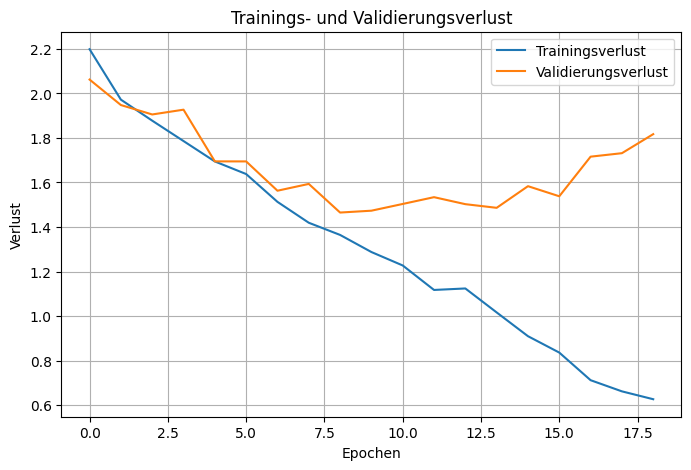

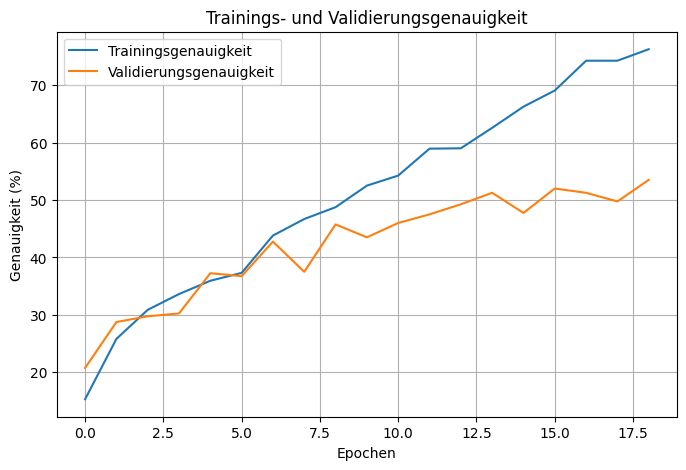

In [72]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


# --V2.1-- Die Anzahl der Convolutional Layer wurde Layer auf "4" reduziert.

In [73]:
import torch.nn as nn
import torch.optim as optim

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(256 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(torch.relu(self.conv2(x)))  # 16x16 -> 8x8
        x = self.pool(torch.relu(self.conv3(x)))  # 8x8 -> 4x4
        x = self.pool(torch.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Modell initialisieren
model = CNN()

# GPU verwenden, falls verfügbar
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Verlustfunktion und Optimierer definieren
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4- Training und Validierung definieren

In [74]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 50  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/50] Train Loss: 2.2143 | Train Acc: 16.69% || Val Loss: 2.0607 | Val Acc: 23.25%
Epoche [2/50] Train Loss: 1.9701 | Train Acc: 27.94% || Val Loss: 1.9975 | Val Acc: 29.00%
Epoche [3/50] Train Loss: 1.8710 | Train Acc: 30.69% || Val Loss: 1.8113 | Val Acc: 32.00%
Epoche [4/50] Train Loss: 1.7525 | Train Acc: 34.25% || Val Loss: 1.7549 | Val Acc: 36.25%
Epoche [5/50] Train Loss: 1.6776 | Train Acc: 37.56% || Val Loss: 1.6358 | Val Acc: 38.25%
Epoche [6/50] Train Loss: 1.5974 | Train Acc: 39.69% || Val Loss: 1.6156 | Val Acc: 41.75%
Epoche [7/50] Train Loss: 1.4894 | Train Acc: 44.81% || Val Loss: 1.6418 | Val Acc: 44.25%
🛑 Early-Stopping-Warnung: 1/10
Epoche [8/50] Train Loss: 1.4273 | Train Acc: 47.25% || Val Loss: 1.5247 | Val Acc: 43.00%
Epoche [9/50] Train Loss: 1.3223 | Train Acc: 49.88% || Val Loss: 1.4720 | Val Acc: 46.25%
Epoche [10/50] Train Loss: 1.2276 | Train Acc: 55.12% || Val Loss: 1.4114 | Val Acc: 47.75%
Epoche [11/50] Train Loss: 1.1562 | Train Acc: 58.50% || V

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [33]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # 🔍 Sınıf bazlı doğru/yanlış sayımı
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 2.0624
Test Genauigkeit: 53.60%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                66.00
Auto                    76.00
Vogel                   40.00
Katze                   46.00
Hirsch                  30.00
Hund                    44.00
Frosch                  64.00
Pferd                   60.00
Schiff                  68.00
LKW                     42.00


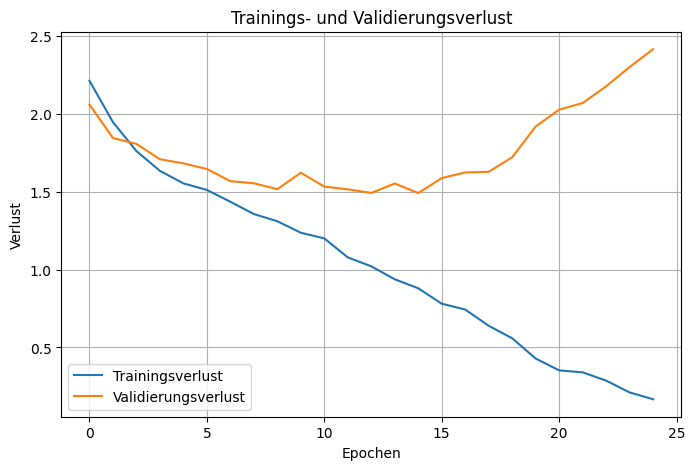

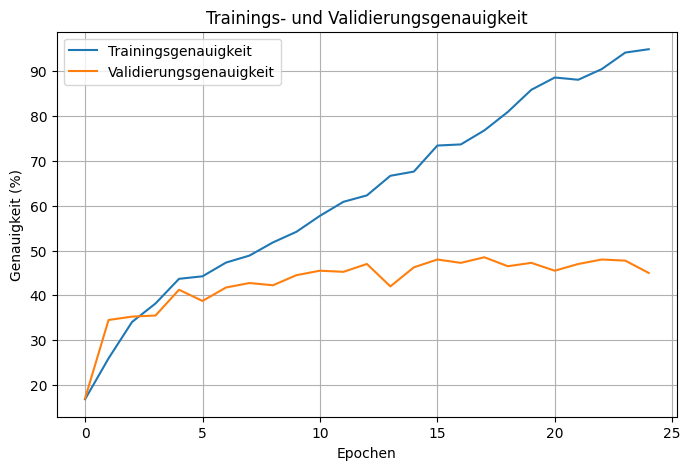

In [34]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


# --V2.2-- Die Anzahl der Convolutional wurde Layer auf "3" reduziert, und es wurde ein besseres Validierungsergebnis erzielt.

In [27]:
import torch.nn as nn
import torch.optim as optim

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(torch.relu(self.conv2(x)))  # 16x16 -> 8x8
        x = self.pool(torch.relu(self.conv3(x)))  # 8x8 -> 4x4
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Modell initialisieren
model = CNN()

# GPU verwenden, falls verfügbar
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Verlustfunktion und Optimierer definieren
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4- Training und Validierung definieren

In [28]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 50  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/50] Train Loss: 2.1839 | Train Acc: 18.00% || Val Loss: 1.9990 | Val Acc: 27.75%
Epoche [2/50] Train Loss: 1.9230 | Train Acc: 30.44% || Val Loss: 1.8556 | Val Acc: 35.25%
Epoche [3/50] Train Loss: 1.7588 | Train Acc: 36.75% || Val Loss: 1.7479 | Val Acc: 37.50%
Epoche [4/50] Train Loss: 1.6307 | Train Acc: 40.62% || Val Loss: 1.7797 | Val Acc: 35.75%
🛑 Early-Stopping-Warnung: 1/10
Epoche [5/50] Train Loss: 1.4794 | Train Acc: 46.56% || Val Loss: 1.6238 | Val Acc: 39.25%
Epoche [6/50] Train Loss: 1.4265 | Train Acc: 48.88% || Val Loss: 1.6192 | Val Acc: 40.25%
Epoche [7/50] Train Loss: 1.2964 | Train Acc: 53.88% || Val Loss: 1.5188 | Val Acc: 43.75%
Epoche [8/50] Train Loss: 1.2458 | Train Acc: 53.62% || Val Loss: 1.5666 | Val Acc: 42.00%
🛑 Early-Stopping-Warnung: 1/10
Epoche [9/50] Train Loss: 1.1729 | Train Acc: 59.00% || Val Loss: 1.5363 | Val Acc: 46.25%
🛑 Early-Stopping-Warnung: 2/10
Epoche [10/50] Train Loss: 1.0956 | Train Acc: 60.19% || Val Loss: 1.4345 | Val Acc: 46.

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [29]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 1.8158
Test Genauigkeit: 49.60%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                62.00
Auto                    82.00
Vogel                   36.00
Katze                   28.00
Hirsch                  32.00
Hund                    36.00
Frosch                  54.00
Pferd                   54.00
Schiff                  74.00
LKW                     38.00


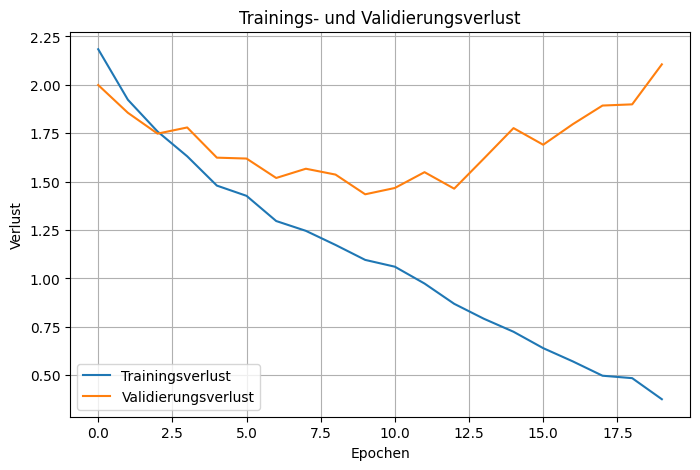

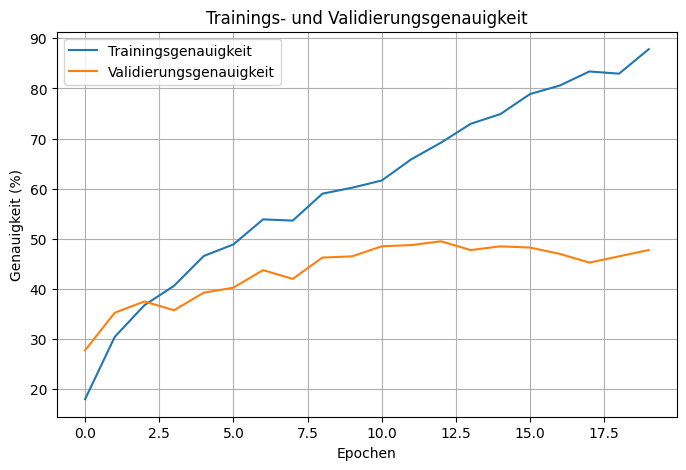

In [30]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


# --V3-- "Dropout" wurde angewendet und gute Ergebnisse wurden erzielt. Dadurch wurde Overfitting reduziert.

In [35]:
# Schritt 2: Datenvorbereitung

# Transformationen (Normalisierung und ggf. Augmentierung)
# Transformation festlegen: Bilder in Tensor umwandeln und normalisieren


transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Augmentierung nur hier!
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

In [36]:
# DataLoader erzeugen (Batchgröße = 4)

batch_size = 64

# DataLoader erstellen
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader   = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


# Klassen definieren (auf Deutsch)
classes = ('Flugzeug', 'Auto', 'Vogel', 'Katze', 'Hirsch',
           'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW')

## 3- Modelldefinition für CIFAR-10 (3 Cv Layer + Dropout)

In [39]:
import torch.nn as nn
import torch.optim as optim

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)  # Dropout oranı

        # Fully Connected
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)  # CIFAR-10 için 10 sınıf

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv3(x)))
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = nn.ReLU()(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4- Training und Validierung definieren

In [40]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 50  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/50] Train Loss: 2.2634 | Train Acc: 14.81% || Val Loss: 2.1755 | Val Acc: 18.25%
Epoche [2/50] Train Loss: 2.1210 | Train Acc: 21.12% || Val Loss: 2.0832 | Val Acc: 27.00%
Epoche [3/50] Train Loss: 2.0200 | Train Acc: 25.88% || Val Loss: 1.9091 | Val Acc: 31.75%
Epoche [4/50] Train Loss: 1.8791 | Train Acc: 31.56% || Val Loss: 1.9064 | Val Acc: 32.00%
Epoche [5/50] Train Loss: 1.8082 | Train Acc: 34.69% || Val Loss: 1.8169 | Val Acc: 38.50%
Epoche [6/50] Train Loss: 1.7504 | Train Acc: 35.25% || Val Loss: 1.7399 | Val Acc: 40.00%
Epoche [7/50] Train Loss: 1.6612 | Train Acc: 39.50% || Val Loss: 1.7245 | Val Acc: 36.75%
Epoche [8/50] Train Loss: 1.6051 | Train Acc: 41.88% || Val Loss: 1.6332 | Val Acc: 38.75%
Epoche [9/50] Train Loss: 1.5734 | Train Acc: 40.81% || Val Loss: 1.6442 | Val Acc: 40.75%
🛑 Early-Stopping-Warnung: 1/10
Epoche [10/50] Train Loss: 1.5359 | Train Acc: 44.44% || Val Loss: 1.5978 | Val Acc: 41.25%
Epoche [11/50] Train Loss: 1.4948 | Train Acc: 46.38% || V

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [41]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

# Sınıf bazlı sayım için:
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 1.3997
Test Genauigkeit: 57.00%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                54.00
Auto                    68.00
Vogel                   52.00
Katze                   36.00
Hirsch                  44.00
Hund                    54.00
Frosch                  64.00
Pferd                   66.00
Schiff                  70.00
LKW                     62.00


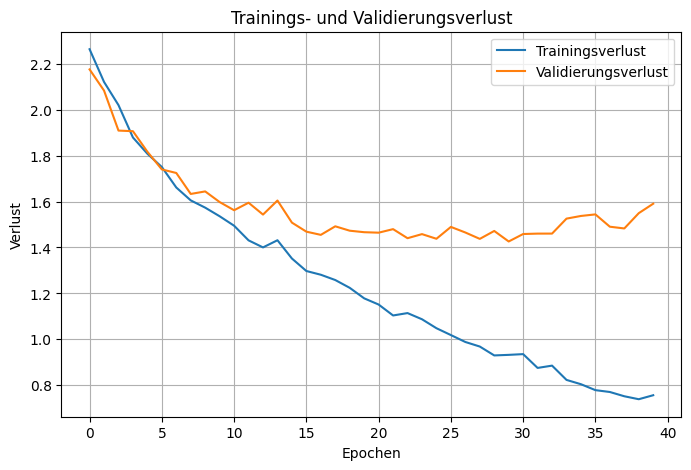

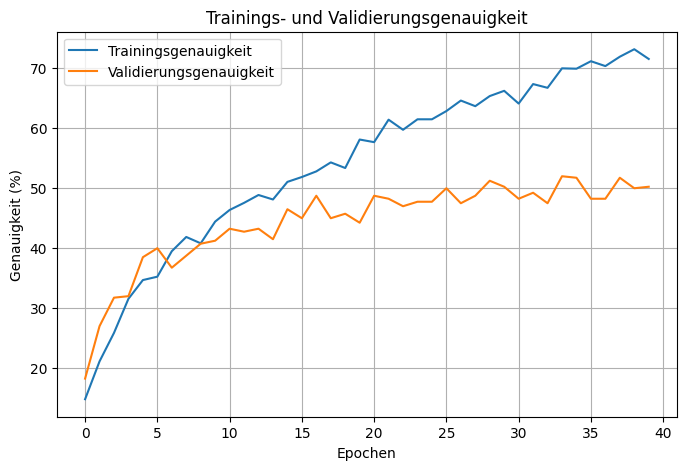

In [42]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


# --V4-- Die Anzahl der "Batch_size" wurde Layer auf "32" reduziert.

In [47]:
# Schritt 2: Datenvorbereitung

# Transformationen (Normalisierung und ggf. Augmentierung)
# Transformation festlegen: Bilder in Tensor umwandeln und normalisieren


transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Augmentierung nur hier!
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

In [48]:
# DataLoader erzeugen (Batchgröße = 4)

batch_size = 32

# DataLoader erstellen
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader   = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


# Klassen definieren (auf Deutsch)
classes = ('Flugzeug', 'Auto', 'Vogel', 'Katze', 'Hirsch',
           'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW')

## 3- Modelldefinition für CIFAR-10 (3 Cv Layer + Dropout)

In [49]:
import torch.nn as nn
import torch.optim as optim

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolutional katmanlar
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        # Fully Connected
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)  # CIFAR-10 için 10 sınıf

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv3(x)))
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = nn.ReLU()(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4- Training und Validierung definieren

In [50]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 50  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/50] Train Loss: 2.2165 | Train Acc: 16.75% || Val Loss: 2.0617 | Val Acc: 25.75%
Epoche [2/50] Train Loss: 2.0070 | Train Acc: 25.12% || Val Loss: 1.9385 | Val Acc: 30.75%
Epoche [3/50] Train Loss: 1.8584 | Train Acc: 31.31% || Val Loss: 1.8189 | Val Acc: 33.50%
Epoche [4/50] Train Loss: 1.7532 | Train Acc: 35.50% || Val Loss: 1.7572 | Val Acc: 32.75%
Epoche [5/50] Train Loss: 1.6781 | Train Acc: 36.62% || Val Loss: 1.7095 | Val Acc: 38.25%
Epoche [6/50] Train Loss: 1.6310 | Train Acc: 39.56% || Val Loss: 1.6437 | Val Acc: 39.50%
Epoche [7/50] Train Loss: 1.5255 | Train Acc: 43.62% || Val Loss: 1.5983 | Val Acc: 39.50%
Epoche [8/50] Train Loss: 1.5159 | Train Acc: 42.69% || Val Loss: 1.5267 | Val Acc: 43.25%
Epoche [9/50] Train Loss: 1.4840 | Train Acc: 46.19% || Val Loss: 1.5731 | Val Acc: 42.00%
🛑 Early-Stopping-Warnung: 1/10
Epoche [10/50] Train Loss: 1.4119 | Train Acc: 48.31% || Val Loss: 1.5335 | Val Acc: 44.25%
🛑 Early-Stopping-Warnung: 2/10
Epoche [11/50] Train Loss: 

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [51]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

# Sınıf bazlı sayım için:
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 1.3373
Test Genauigkeit: 51.80%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                36.00
Auto                    70.00
Vogel                   44.00
Katze                   34.00
Hirsch                  34.00
Hund                    56.00
Frosch                  54.00
Pferd                   62.00
Schiff                  72.00
LKW                     56.00


In [ ]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


# --V5-- Leaky Relu wurde benutzt Anstatt Relu.

In [81]:
# Schritt 2: Datenvorbereitung

# Transformationen (Normalisierung und ggf. Augmentierung)
# Transformation festlegen: Bilder in Tensor umwandeln und normalisieren


transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Augmentierung nur hier!
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

In [82]:
# DataLoader erzeugen (Batchgröße = 4)

batch_size = 32

# DataLoader erstellen
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader   = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


# Klassen definieren (auf Deutsch)
classes = ('Flugzeug', 'Auto', 'Vogel', 'Katze', 'Hirsch',
           'Hund', 'Frosch', 'Pferd', 'Schiff', 'LKW')

## 3- Modelldefinition für CIFAR-10 (3 Cv Layer + Dropout)

In [83]:
import torch.nn as nn
import torch.optim as optim

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        # Fully Connected
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

        # LeakyReLU  (slope=0.01)
        self.activation = nn.LeakyReLU()

    def forward(self, x):
        x = self.pool(self.activation(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(self.activation(self.conv2(x)))
        x = self.dropout(x)
        x = self.pool(self.activation(self.conv3(x)))
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (activation): LeakyReLU(negative_slope=0.01)
)


## 4- Training und Validierung definieren

In [84]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 50  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/50] Train Loss: 2.2171 | Train Acc: 17.50% || Val Loss: 2.1055 | Val Acc: 24.00%
Epoche [2/50] Train Loss: 2.0054 | Train Acc: 26.12% || Val Loss: 1.9713 | Val Acc: 30.00%
Epoche [3/50] Train Loss: 1.8573 | Train Acc: 32.62% || Val Loss: 1.8130 | Val Acc: 33.00%
Epoche [4/50] Train Loss: 1.7704 | Train Acc: 35.00% || Val Loss: 1.6711 | Val Acc: 42.75%
Epoche [5/50] Train Loss: 1.6664 | Train Acc: 38.62% || Val Loss: 1.6324 | Val Acc: 39.75%
Epoche [6/50] Train Loss: 1.5859 | Train Acc: 41.06% || Val Loss: 1.5892 | Val Acc: 46.25%
Epoche [7/50] Train Loss: 1.5597 | Train Acc: 41.50% || Val Loss: 1.5744 | Val Acc: 41.50%
Epoche [8/50] Train Loss: 1.4975 | Train Acc: 43.25% || Val Loss: 1.5087 | Val Acc: 44.25%
Epoche [9/50] Train Loss: 1.4414 | Train Acc: 46.88% || Val Loss: 1.4017 | Val Acc: 51.00%
Epoche [10/50] Train Loss: 1.3660 | Train Acc: 50.75% || Val Loss: 1.4063 | Val Acc: 50.00%
🛑 Early-Stopping-Warnung: 1/10
Epoche [11/50] Train Loss: 1.3276 | Train Acc: 50.25% || V

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [85]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 1.5360
Test Genauigkeit: 48.80%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                60.00
Auto                    70.00
Vogel                   36.00
Katze                   32.00
Hirsch                  26.00
Hund                    48.00
Frosch                  58.00
Pferd                   48.00
Schiff                  60.00
LKW                     50.00


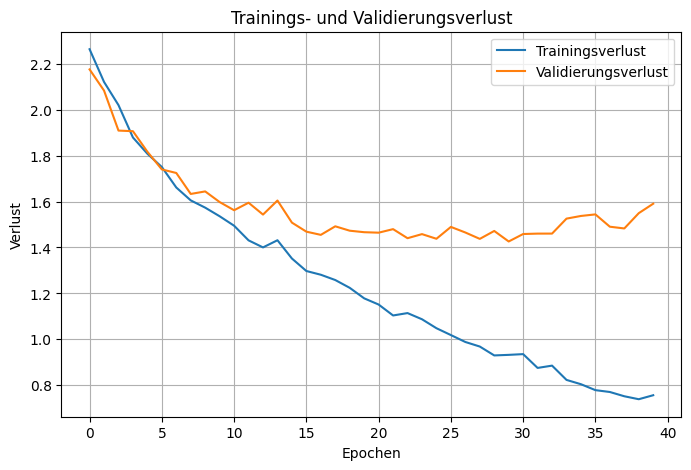

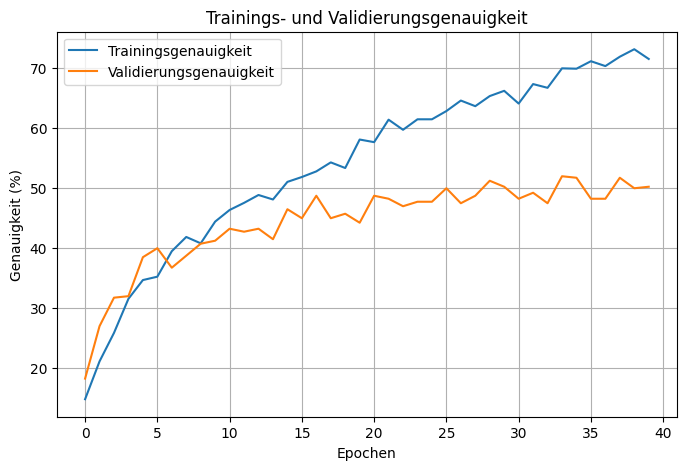

In [ ]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


# --V6-- 'SGD' wurde anstatt 'Adam' benutzt

In [91]:
import torch.nn as nn
import torch.optim as optim

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)  # Dropout oranı

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)  # CIFAR-10 için 10 sınıf

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv3(x)))
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = nn.ReLU()(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4- Training und Validierung definieren

In [92]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 50  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/50] Train Loss: 2.2855 | Train Acc: 12.19% || Val Loss: 2.2230 | Val Acc: 24.50%
Epoche [2/50] Train Loss: 2.0950 | Train Acc: 23.00% || Val Loss: 2.0330 | Val Acc: 27.75%
Epoche [3/50] Train Loss: 1.9878 | Train Acc: 26.69% || Val Loss: 2.0228 | Val Acc: 27.50%
Epoche [4/50] Train Loss: 1.9150 | Train Acc: 31.25% || Val Loss: 1.8665 | Val Acc: 32.00%
Epoche [5/50] Train Loss: 1.8227 | Train Acc: 33.56% || Val Loss: 1.8404 | Val Acc: 37.25%
Epoche [6/50] Train Loss: 1.7525 | Train Acc: 36.19% || Val Loss: 1.6867 | Val Acc: 37.50%
Epoche [7/50] Train Loss: 1.6724 | Train Acc: 38.56% || Val Loss: 1.6232 | Val Acc: 39.25%
Epoche [8/50] Train Loss: 1.6251 | Train Acc: 39.00% || Val Loss: 1.5778 | Val Acc: 44.50%
Epoche [9/50] Train Loss: 1.5867 | Train Acc: 42.06% || Val Loss: 1.5800 | Val Acc: 43.00%
🛑 Early-Stopping-Warnung: 1/10
Epoche [10/50] Train Loss: 1.5727 | Train Acc: 41.88% || Val Loss: 1.4845 | Val Acc: 44.50%
Epoche [11/50] Train Loss: 1.5169 | Train Acc: 43.19% || V

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [88]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 1.4871
Test Genauigkeit: 50.00%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                42.00
Auto                    66.00
Vogel                   44.00
Katze                   34.00
Hirsch                  64.00
Hund                    34.00
Frosch                  46.00
Pferd                   50.00
Schiff                  74.00
LKW                     46.00


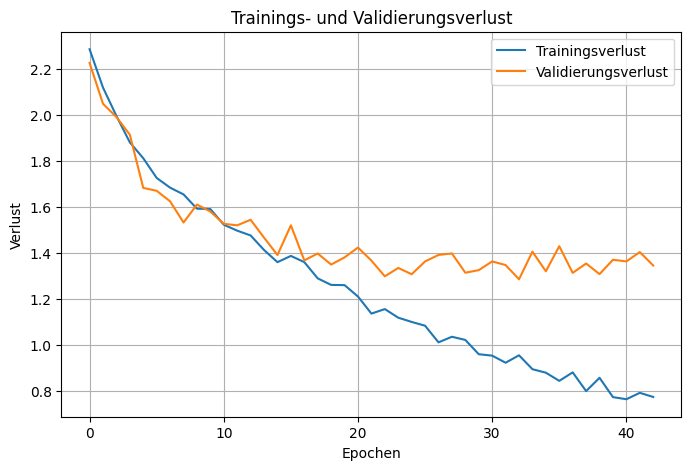

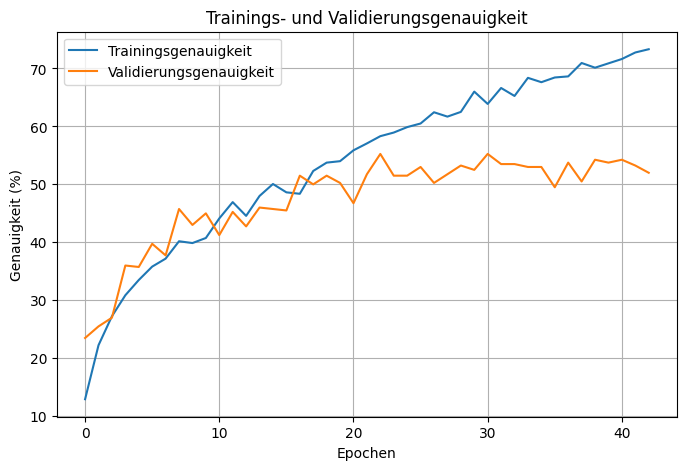

In [89]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


# --V7-- NLLLos wurde anstatt 'CrossEntropy' benutzt.

In [93]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv3(x)))
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = nn.ReLU()(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)


model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4- Training und Validierung definieren

In [94]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 50  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/50] Train Loss: 2.2288 | Train Acc: 16.19% || Val Loss: 2.0543 | Val Acc: 25.50%
Epoche [2/50] Train Loss: 1.9698 | Train Acc: 26.81% || Val Loss: 1.8616 | Val Acc: 32.50%
Epoche [3/50] Train Loss: 1.8276 | Train Acc: 33.00% || Val Loss: 1.7063 | Val Acc: 40.50%
Epoche [4/50] Train Loss: 1.7004 | Train Acc: 37.69% || Val Loss: 1.6417 | Val Acc: 40.25%
Epoche [5/50] Train Loss: 1.6415 | Train Acc: 38.81% || Val Loss: 1.5520 | Val Acc: 40.50%
Epoche [6/50] Train Loss: 1.5864 | Train Acc: 40.88% || Val Loss: 1.5205 | Val Acc: 43.25%
Epoche [7/50] Train Loss: 1.5451 | Train Acc: 43.69% || Val Loss: 1.5114 | Val Acc: 46.25%
Epoche [8/50] Train Loss: 1.4571 | Train Acc: 47.25% || Val Loss: 1.4524 | Val Acc: 49.00%
Epoche [9/50] Train Loss: 1.4011 | Train Acc: 47.19% || Val Loss: 1.4728 | Val Acc: 44.00%
🛑 Early-Stopping-Warnung: 1/10
Epoche [10/50] Train Loss: 1.3654 | Train Acc: 49.31% || Val Loss: 1.4136 | Val Acc: 49.00%
Epoche [11/50] Train Loss: 1.3164 | Train Acc: 51.88% || V

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [95]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 1.4128
Test Genauigkeit: 51.20%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                42.00
Auto                    62.00
Vogel                   46.00
Katze                   38.00
Hirsch                  36.00
Hund                    44.00
Frosch                  58.00
Pferd                   54.00
Schiff                  78.00
LKW                     54.00


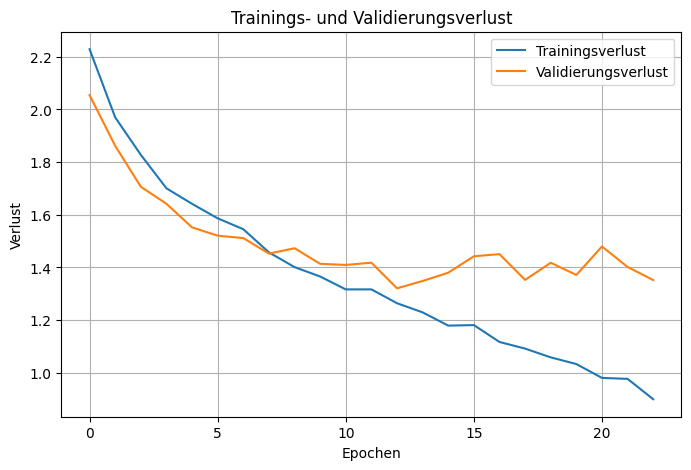

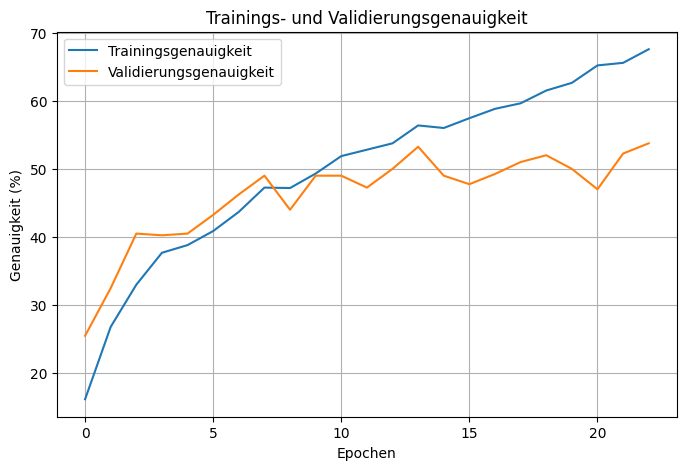

In [96]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


# --V8-- Lernrate wurde auf "0.0001" reduziert, und es wurde ein besseres Validierungsergebnis erzielt.

In [97]:
import torch.nn as nn
import torch.optim as optim

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)  # CIFAR-10 için 10 sınıf

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = self.dropout(x)
        x = self.pool(nn.ReLU()(self.conv3(x)))
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = nn.ReLU()(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4- Training und Validierung definieren

In [98]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 100  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/100] Train Loss: 2.2915 | Train Acc: 11.62% || Val Loss: 2.2773 | Val Acc: 14.00%
Epoche [2/100] Train Loss: 2.2180 | Train Acc: 18.25% || Val Loss: 2.1739 | Val Acc: 25.75%
Epoche [3/100] Train Loss: 2.0821 | Train Acc: 24.69% || Val Loss: 2.0796 | Val Acc: 25.25%
Epoche [4/100] Train Loss: 2.0308 | Train Acc: 24.69% || Val Loss: 2.0168 | Val Acc: 26.50%
Epoche [5/100] Train Loss: 1.9513 | Train Acc: 29.44% || Val Loss: 1.9490 | Val Acc: 30.50%
Epoche [6/100] Train Loss: 1.9271 | Train Acc: 28.75% || Val Loss: 1.9330 | Val Acc: 28.50%
Epoche [7/100] Train Loss: 1.8983 | Train Acc: 30.12% || Val Loss: 1.9057 | Val Acc: 29.50%
Epoche [8/100] Train Loss: 1.8859 | Train Acc: 31.31% || Val Loss: 1.8759 | Val Acc: 35.00%
Epoche [9/100] Train Loss: 1.8506 | Train Acc: 32.88% || Val Loss: 1.8455 | Val Acc: 39.00%
Epoche [10/100] Train Loss: 1.8306 | Train Acc: 33.56% || Val Loss: 1.8222 | Val Acc: 35.50%
Epoche [11/100] Train Loss: 1.7871 | Train Acc: 34.94% || Val Loss: 1.7930 | Va

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [99]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # 🔍 Sınıf bazlı doğru/yanlış sayımı
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

# 📋 Sınıf bazlı tablo
print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 1.4449
Test Genauigkeit: 47.40%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                46.00
Auto                    70.00
Vogel                   26.00
Katze                   36.00
Hirsch                  34.00
Hund                    42.00
Frosch                  60.00
Pferd                   46.00
Schiff                  58.00
LKW                     56.00


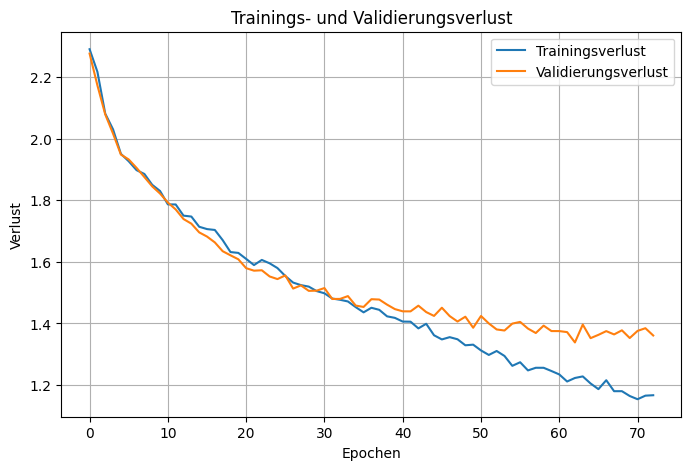

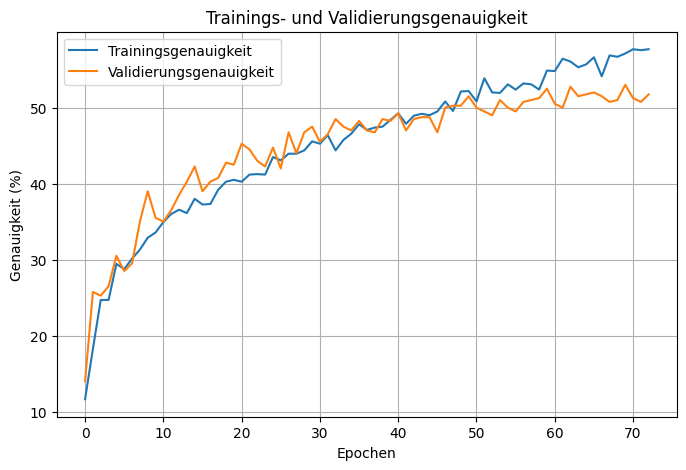

In [100]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()


# --V8.2-- Lernrate wurde auf "0.0005" reduziert, und es wurde ein besseres Validierungsergebnis erzielt.

In [101]:
import torch.nn as nn
import torch.optim as optim

# Modelldefinition angepasst auf CIFAR-10
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(512 * 1 * 1, 128)  # <-- wichtig: 64 * 8 * 8 (für CIFAR-10)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # 32x32 -> 16x16
        x = self.pool(torch.relu(self.conv2(x)))  # 16x16 -> 8x8
        x = self.pool(torch.relu(self.conv3(x)))  # 8x8 -> 4x4
        x = self.pool(torch.relu(self.conv4(x)))  # 4x4 -> 2x2
        x = self.pool(torch.relu(self.conv5(x)))  # 2x2 -> 1x1
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Modell initialisieren
model = CNN()

# GPU verwenden, falls verfügbar
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Verlustfunktion und Optimierer definieren
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00005)

print(model)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 4- Training und Validierung definieren

In [102]:
best_val_loss = float('inf')
patience = 10
trigger_times = 0

num_epochs = 100  # Anzahl der Epochen festlegen

# Listen für Ergebnisse
train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Gradienten auf Null setzen
        optimizer.zero_grad()

        # Forward + Backward + Optimierung
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Verlust und Genauigkeit berechnen
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    # Validierung
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_epoch_loss = val_loss / len(val_loader)
    val_epoch_acc = 100. * correct_val / total_val
    val_losses.append(val_epoch_loss)
    val_acc.append(val_epoch_acc)

    print(f'Epoche [{epoch+1}/{num_epochs}] '
          f'Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% '
          f'|| Val Loss: {val_epoch_loss:.4f} | Val Acc: {val_epoch_acc:.2f}%')

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"🛑 Early-Stopping-Warnung: {trigger_times}/{patience}")
        if trigger_times >= patience:
            print("⛔️ Training gestoppt: Validierungsverlust hat sich nicht verbessert.")
            break

print("Training abgeschlossen!")


Epoche [1/100] Train Loss: 2.2937 | Train Acc: 13.00% || Val Loss: 2.2795 | Val Acc: 10.50%
Epoche [2/100] Train Loss: 2.2163 | Train Acc: 18.44% || Val Loss: 2.1413 | Val Acc: 23.75%
Epoche [3/100] Train Loss: 2.0569 | Train Acc: 25.06% || Val Loss: 2.0590 | Val Acc: 26.50%
Epoche [4/100] Train Loss: 1.9806 | Train Acc: 26.62% || Val Loss: 1.9705 | Val Acc: 26.00%
Epoche [5/100] Train Loss: 1.9357 | Train Acc: 29.88% || Val Loss: 1.9544 | Val Acc: 26.50%
Epoche [6/100] Train Loss: 1.9135 | Train Acc: 30.00% || Val Loss: 1.9381 | Val Acc: 27.50%
Epoche [7/100] Train Loss: 1.8958 | Train Acc: 30.69% || Val Loss: 1.9206 | Val Acc: 29.50%
Epoche [8/100] Train Loss: 1.8650 | Train Acc: 31.81% || Val Loss: 1.8951 | Val Acc: 32.50%
Epoche [9/100] Train Loss: 1.8438 | Train Acc: 34.12% || Val Loss: 1.8685 | Val Acc: 34.00%
Epoche [10/100] Train Loss: 1.8240 | Train Acc: 33.31% || Val Loss: 1.8654 | Val Acc: 31.25%
Epoche [11/100] Train Loss: 1.7872 | Train Acc: 35.19% || Val Loss: 1.8309 | Va

## Schritt 5: Evaluation (Test-Genauigkeit berechnen)

In [103]:
# 📌 Model evaluieren (test accuracy + loss)
model.eval()

correct = 0
total = 0
test_loss = 0.0

class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

test_accuracy = 100. * correct / total
test_loss_avg = test_loss / len(testloader)

print(f"\nTest Loss: {test_loss_avg:.4f}")
print(f"Test Genauigkeit: {test_accuracy:.2f}%")

print("\n🔎 Klassengenauigkeiten:")
print(f"{'Klasse':<12} {'Genauigkeit (%)':>18}")
print("-" * 32)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"{classes[i]:<12} {acc:>16.2f}")



Test Loss: 1.6772
Test Genauigkeit: 40.20%

🔎 Klassengenauigkeiten:
Klasse          Genauigkeit (%)
--------------------------------
Flugzeug                32.00
Auto                    64.00
Vogel                   20.00
Katze                   16.00
Hirsch                  26.00
Hund                    58.00
Frosch                  48.00
Pferd                   28.00
Schiff                  60.00
LKW                     50.00


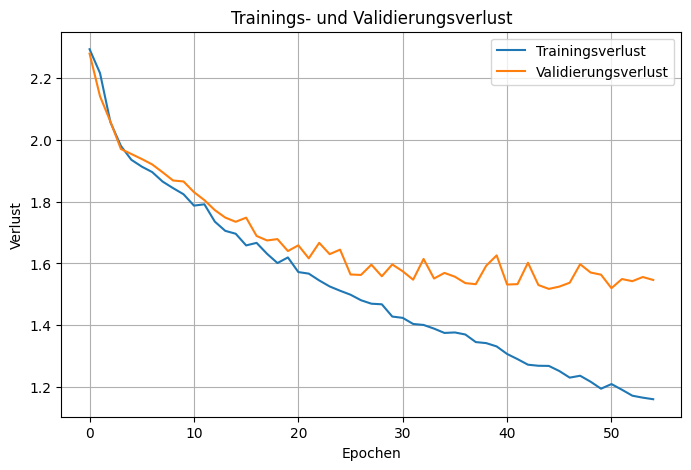

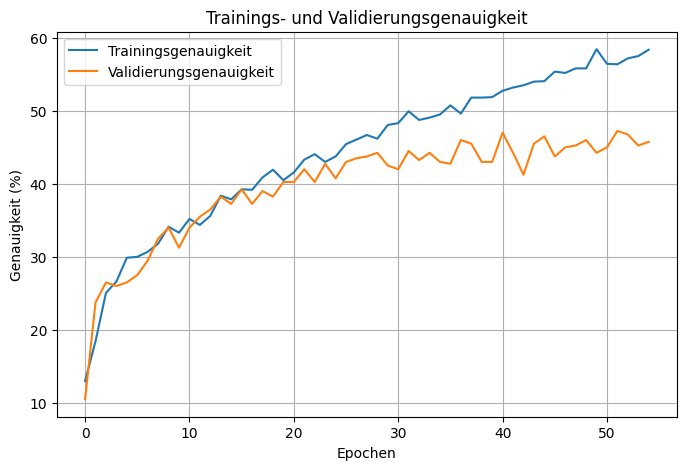

In [104]:
# Visualisierung der Verlustkurven
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Trainingsverlust')
plt.plot(val_losses, label='Validierungsverlust')
plt.xlabel('Epochen')
plt.ylabel('Verlust')
plt.title('Trainings- und Validierungsverlust')
plt.legend()
plt.grid()
plt.show()

# Visualisierung der Genauigkeitskurven
plt.figure(figsize=(8, 5))
plt.plot(train_acc, label='Trainingsgenauigkeit')
plt.plot(val_acc, label='Validierungsgenauigkeit')
plt.xlabel('Epochen')
plt.ylabel('Genauigkeit (%)')
plt.title('Trainings- und Validierungsgenauigkeit')
plt.legend()
plt.grid()
plt.show()
